<a href="https://colab.research.google.com/github/Brenon934/Engenharia_de_Prompt_e_Aplicacao_IA/blob/main/Unidade_02/Atividade_aula08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Aula 13/04 - Automação com I.A, e exercícios práticos com o Gemini(Leitura de Script, Ghostwriter e tratamento de Erros):

**Nome:** Brenon Rodrigo A. M. Coutinho

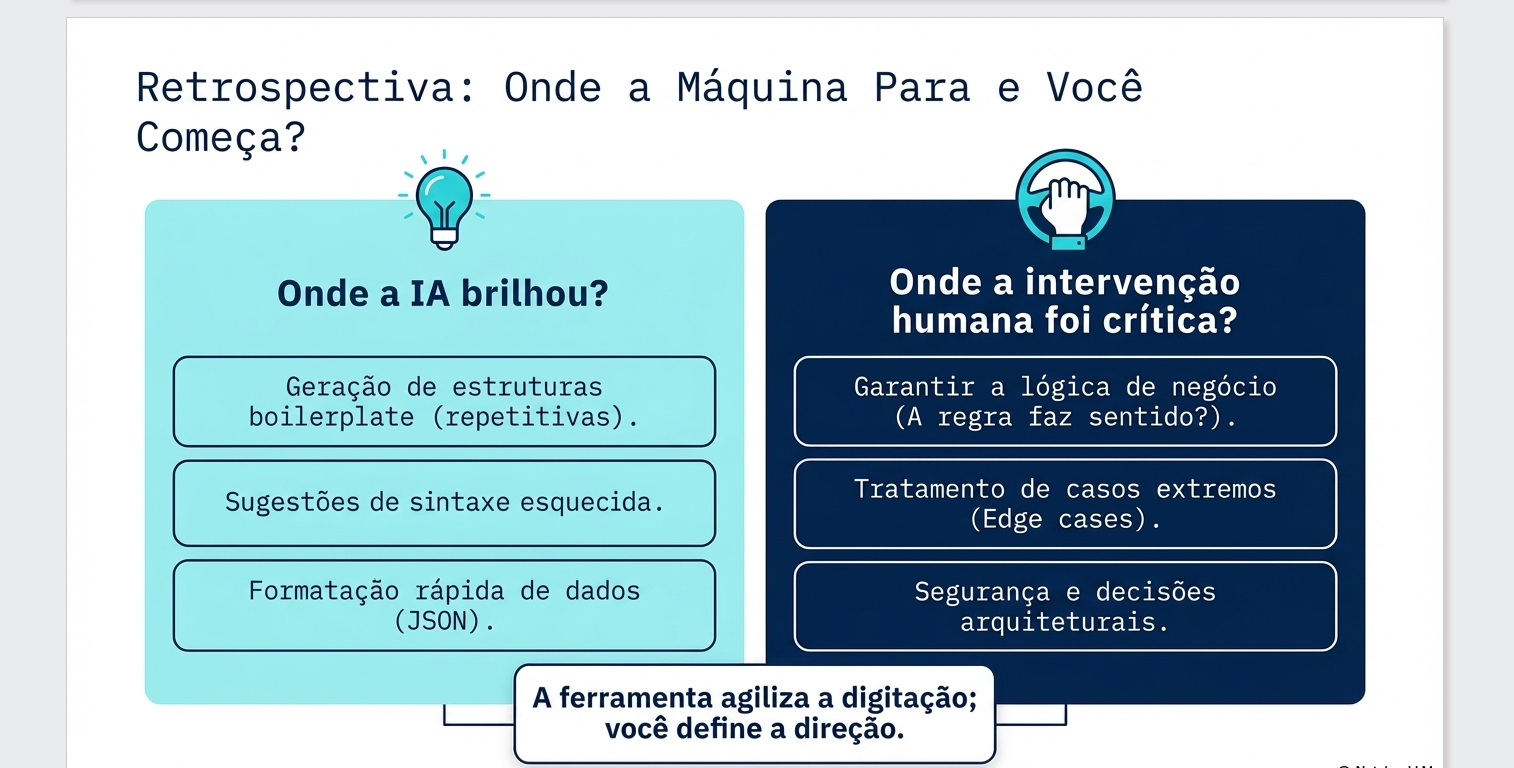

## **01-Automação de arquivos:**
**Criar um programa que organize arquivos em pastas baseando-se apenas na extensão.**


In [1]:
import os
import shutil
import tempfile

# Dicionário que mapeia extensões de arquivo para nomes de pastas
# Você pode adicionar mais tipos conforme necessário
TIPOS_DE_ARQUIVOS = {
    '.pdf': 'Documentos PDF',
    '.doc': 'Documentos Word',
    '.docx': 'Documentos Word',
    '.xls': 'Planilhas Excel',
    '.xlsx': 'Planilhas Excel',
    '.ppt': 'Apresentações PowerPoint',
    '.pptx': 'Apresentações PowerPoint',
    '.png': 'Imagens PNG',
    '.jpg': 'Imagens JPG',
    '.jpeg': 'Imagens JPEG',
    '.gif': 'Imagens GIF',
    '.txt': 'Arquivos de Texto',
    '.zip': 'Arquivos Compactados',
    '.rar': 'Arquivos Compactados',
    '.mp3': 'Músicas',
    '.wav': 'Músicas',
    '.mp4': 'Vídeos',
    '.avi': 'Vídeos',
    '.mov': 'Vídeos',
    '.py': 'Scripts Python',
    '.ipynb': 'Notebooks Jupyter'
}

def organizar_arquivos(diretorio_origem='.'):
    """
    Organiza arquivos em pastas baseadas em suas extensões no diretório especificado.
    Cria pastas para tipos de documentos comuns (.pdf, .doc, .xls, .png, etc.)
    e move os arquivos para elas. Funciona sem permissões de administrador
    desde que o diretorio_origem seja acessível ao usuário.
    """

    print(f"\nIniciando organização de arquivos em: {os.path.abspath(diretorio_origem)}")

    # Itera sobre todos os itens no diretório de origem
    for nome_arquivo in os.listdir(diretorio_origem):
        caminho_completo_arquivo = os.path.join(diretorio_origem, nome_arquivo)

        # Ignora diretórios
        if os.path.isdir(caminho_completo_arquivo):
            continue

        # Obtém a extensão do arquivo em minúsculas
        _, extensao = os.path.splitext(nome_arquivo)
        extensao = extensao.lower()

        # Verifica se a extensão está no nosso dicionário de tipos
        if extensao in TIPOS_DE_ARQUIVOS:
            nome_pasta = TIPOS_DE_ARQUIVOS[extensao]
        else:
            # Se não for um tipo conhecido, coloca em uma pasta 'Outros'
            nome_pasta = 'Outros'

        # Define o caminho completo para a pasta de destino
        caminho_pasta_destino = os.path.join(diretorio_origem, nome_pasta)

        # Cria a pasta de destino se ela não existir
        if not os.path.exists(caminho_pasta_destino):
            os.makedirs(caminho_pasta_destino)
            print(f"Pasta '{nome_pasta}' criada.")

        # Define o caminho completo do arquivo no destino
        caminho_destino_arquivo = os.path.join(caminho_pasta_destino, nome_arquivo)

        try:
            # Move o arquivo para a pasta de destino
            shutil.move(caminho_completo_arquivo, caminho_destino_arquivo)
            print(f"Arquivo '{nome_arquivo}' movido para '{nome_pasta}'.")
        except Exception as e:
            print(f"Erro ao mover o arquivo '{nome_arquivo}': {e}")

    print("Organização de arquivos concluída!")


def criar_arquivos_teste(diretorio_origem, tipos_de_arquivos_dict, num_arquivos_por_extensao=3):
    """
    Cria arquivos de teste no diretório especificado para simular a organização.
    """
    print(f"\nCriando {num_arquivos_por_extensao} arquivos de teste para cada extensão em: {diretorio_origem}")
    for extensao in tipos_de_arquivos_dict.keys():
        for i in range(1, num_arquivos_por_extensao + 1):
            nome_arquivo = f"arquivo_teste_{i}{extensao}"
            caminho_arquivo = os.path.join(diretorio_origem, nome_arquivo)
            with open(caminho_arquivo, 'w') as f:
                f.write(f"Conteúdo de teste para {nome_arquivo}")
            print(f"Criado: {nome_arquivo}")

# --- EXECUTAR O SCRIPT --- Com simulação de arquivos de teste
print("O diretório de trabalho atual é: " + os.getcwd())

temp_dir = None
try:
    # Cria um diretório temporário para a simulação
    temp_dir = tempfile.mkdtemp()
    print(f"Diretório temporário para simulação criado: {temp_dir}")

    # Cria arquivos de teste no diretório temporário
    criar_arquivos_teste(temp_dir, TIPOS_DE_ARQUIVOS, num_arquivos_por_extensao=3)

    # Executa a organização dos arquivos no diretório temporário
    organizar_arquivos(temp_dir)

except Exception as e:
    print(f"Ocorreu um erro durante a simulação: {e}")
finally:
    # Limpa o diretório temporário
    if temp_dir and os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
        print(f"\nDiretório temporário '{temp_dir}' e seu conteúdo foram removidos.")


O diretório de trabalho atual é: /content
Diretório temporário para simulação criado: /tmp/tmph1jfcyb4

Criando 3 arquivos de teste para cada extensão em: /tmp/tmph1jfcyb4
Criado: arquivo_teste_1.pdf
Criado: arquivo_teste_2.pdf
Criado: arquivo_teste_3.pdf
Criado: arquivo_teste_1.doc
Criado: arquivo_teste_2.doc
Criado: arquivo_teste_3.doc
Criado: arquivo_teste_1.docx
Criado: arquivo_teste_2.docx
Criado: arquivo_teste_3.docx
Criado: arquivo_teste_1.xls
Criado: arquivo_teste_2.xls
Criado: arquivo_teste_3.xls
Criado: arquivo_teste_1.xlsx
Criado: arquivo_teste_2.xlsx
Criado: arquivo_teste_3.xlsx
Criado: arquivo_teste_1.ppt
Criado: arquivo_teste_2.ppt
Criado: arquivo_teste_3.ppt
Criado: arquivo_teste_1.pptx
Criado: arquivo_teste_2.pptx
Criado: arquivo_teste_3.pptx
Criado: arquivo_teste_1.png
Criado: arquivo_teste_2.png
Criado: arquivo_teste_3.png
Criado: arquivo_teste_1.jpg
Criado: arquivo_teste_2.jpg
Criado: arquivo_teste_3.jpg
Criado: arquivo_teste_1.jpeg
Criado: arquivo_teste_2.jpeg
Criad

## **02-Consulta Simples de API:**
**Desenvolver um script que consulte uma API pública (ViaCEP) e retorne informações de maneira legível.**

In [2]:
import requests
import json

def consultar_cep(cep):
    """
    Consulta a API ViaCEP para obter informações de endereço.
    Retorna o endereço formatado ou uma mensagem de erro.
    """
    # Remove caracteres não numéricos do CEP
    cep = ''.join(filter(str.isdigit, cep))

    # Validação básica do CEP
    if len(cep) != 8:
        return "Erro: O CEP deve conter exatamente 8 dígitos numéricos."

    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        response = requests.get(url)
        response.raise_for_status()  # Lança uma exceção para status de erro (4xx ou 5xx)
        data = response.json()

        if "erro" in data and data["erro"]:
            return f"Erro: CEP '{cep}' não encontrado."
        else:
            # Formata as informações do endereço
            endereco_formatado = f"Endereço para o CEP {cep}:\n"
            endereco_formatado += f"  Logradouro: {data.get('logradouro', 'N/A')}\n"
            endereco_formatado += f"  Complemento: {data.get('complemento', 'N/A')}\n"
            endereco_formatado += f"  Bairro: {data.get('bairro', 'N/A')}\n"
            endereco_formatado += f"  Localidade: {data.get('localidade', 'N/A')}\n"
            endereco_formatado += f"  UF: {data.get('uf', 'N/A')}\n"
            endereco_formatado += f"  DDD: {data.get('ddd', 'N/A')}\n"
            return endereco_formatado

    except requests.exceptions.RequestException as e:
        return f"Erro de conexão com a API ViaCEP: {e}"
    except json.JSONDecodeError:
        return "Erro: Não foi possível decodificar a resposta da API como JSON."
    except Exception as e:
        return f"Ocorreu um erro inesperado: {e}"

# --- Exemplos de uso do script ---

# Exemplo 1: CEP válido
print(consultar_cep("01001-000"))
print("\n" + "-"*30 + "\n")

# Exemplo 2: CEP inválido (formato)
print(consultar_cep("123"))
print("\n" + "-"*30 + "\n")

# Exemplo 3: CEP não existente
print(consultar_cep("99999999"))
print("\n" + "-"*30 + "\n")

# Exemplo 4: Outro CEP válido
print(consultar_cep("70002900"))


Endereço para o CEP 01001000:
  Logradouro: Praça da Sé
  Complemento: lado ímpar
  Bairro: Sé
  Localidade: São Paulo
  UF: SP
  DDD: 11


------------------------------

Erro: O CEP deve conter exatamente 8 dígitos numéricos.

------------------------------

Erro: CEP '99999999' não encontrado.

------------------------------

Endereço para o CEP 70002900:
  Logradouro: SBN Quadra 1 Bloco A
  Complemento: 
  Bairro: Asa Norte
  Localidade: Brasília
  UF: DF
  DDD: 61



## **03-Sistema de Notificções:**
**Criar um programa autônomo que dispare alertas (mensagens de alerta no console ou E-mail simulado) unicamente quando uma condição crítica for atingida.**

In [3]:
import time
import pandas as pd

def enviar_email_simulado(destinatario, assunto, corpo):
    print(f"\n--- E-MAIL SIMULADO ENVIADO ---")
    print(f"Para: {destinatario}")
    print(f"Assunto: {assunto}")
    print(f"Corpo:\n{corpo}")
    print(f"------------------------------\n")

def checar_condicao_critica(valor_monitorado, limite_critico=90):
    if valor_monitorado > limite_critico:
        return True, f"VALOR CRÍTICO: {valor_monitorado} excedeu o limite de {limite_critico}!"
    else:
        return False, f"Valor atual: {valor_monitorado}. Dentro do limite."

def disparar_alerta(mensagem_critica, valor_monitorado_original):
    print(f"*** ALERTA NO CONSOLE: {mensagem_critica} ***")
    assunto_email = "ALERTA CRÍTICO: Sistema em risco!"
    corpo_email = (
        f"Prezado administrador,\n\n"
        f"A seguinte condição crítica foi detectada:\n{mensagem_critica}\n\n"
        f"Valor monitorado no momento do alerta: {valor_monitorado_original}\n\n"
        f"Por favor, tome as ações necessárias.\n\n"
        f"Atenciosamente,\nSistema de Monitoramento"
    )
    enviar_email_simulado("admin@example.com", assunto_email, corpo_email)

def monitorar_e_alertar():
    print("Iniciando monitoramento...\n")
    valores_exemplo = [75, 82, 89, 91, 88, 95, 70]

    historico = []  # lista para armazenar os resultados

    for i, valor in enumerate(valores_exemplo, start=1):
        print(f"Iteração {i}: Monitorando valor {valor}...")
        condicao_critica, mensagem = checar_condicao_critica(valor)

        if condicao_critica:
            disparar_alerta(mensagem, valor)
            status = "CRÍTICO"
        else:
            print(f"Status: {mensagem}")
            status = "OK"

        historico.append({
            "Iteracao": i,
            "Valor": valor,
            "Status": status,
            "Mensagem": mensagem
        })

        time.sleep(1)

    # Salvar histórico em CSV
    df = pd.DataFrame(historico)
    nome_arquivo = "historico_monitoramento.csv"
    df.to_csv(nome_arquivo, index=False, encoding="utf-8")
    print(f"\nMonitoramento concluído. Histórico salvo em '{nome_arquivo}'.")
    print(df)

# --- Executar ---
monitorar_e_alertar()

Iniciando monitoramento...

Iteração 1: Monitorando valor 75...
Status: Valor atual: 75. Dentro do limite.
Iteração 2: Monitorando valor 82...
Status: Valor atual: 82. Dentro do limite.
Iteração 3: Monitorando valor 89...
Status: Valor atual: 89. Dentro do limite.
Iteração 4: Monitorando valor 91...
*** ALERTA NO CONSOLE: VALOR CRÍTICO: 91 excedeu o limite de 90! ***

--- E-MAIL SIMULADO ENVIADO ---
Para: admin@example.com
Assunto: ALERTA CRÍTICO: Sistema em risco!
Corpo:
Prezado administrador,

A seguinte condição crítica foi detectada:
VALOR CRÍTICO: 91 excedeu o limite de 90!

Valor monitorado no momento do alerta: 91

Por favor, tome as ações necessárias.

Atenciosamente,
Sistema de Monitoramento
------------------------------

Iteração 5: Monitorando valor 88...
Status: Valor atual: 88. Dentro do limite.
Iteração 6: Monitorando valor 95...
*** ALERTA NO CONSOLE: VALOR CRÍTICO: 95 excedeu o limite de 90! ***

--- E-MAIL SIMULADO ENVIADO ---
Para: admin@example.com
Assunto: ALERTA C